In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import re
import surfinBH
import lal
from scipy.optimize import curve_fit,, OptimizeWarning
from scipy.integrate import cumulative_trapezoid
import pandas as pd
import gwsurrogate as gws
import warnings
lal.swig_redirect_standard_output_error(False)
warnings.simplefilter("ignore", OptimizeWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

False

In [2]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [3]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')

Loaded NRSur7dq4EmriRemnant fit.


In [4]:
q = 4        
m1 = q / (1 + q) 
m2 = 1 / (1 + q) 
eta = (m1 * m2) 

chi1_z = 0.4
chi2_z = -0.2

S1 = chi1_z * (m1**2)
S2 = chi2_z * (m2**2)

a = np.linspace(100.0,7.0, 1000)

In [5]:
spin1 = [0.0, 0.0, chi1_z]
spin2 = [0.0, 0.0, chi2_z]
mf_surr, chif_vec, *_ = fit.all(q, spin1, spin2)
chif_surr = np.linalg.norm(chif_vec)
Jf_surr = chif_surr * (mf_surr**2)

S_surr_final = entropy(mf_surr, Jf_surr)
print(S_surr_final)

10.306098068917818


2PN ANALYSIS

In [6]:
# function to calculate the maximum entropy at 2PN
#arXiv:1310.1528
#arXiv:1310.1528
#arXiv:gr-qc/0605140

def get_max_2PN(q, chi1_z, chi2_z, a):
    
    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)
    eta = m1 * m2
    delta = m1 - m2  

    S1 = chi1_z * (m1**2)
    S2 = chi2_z * (m2**2)
    
    S_L = S1 + S2
    Sigma_L = chi1_z * m1 - chi2_z * m2
    
    S_ss = S1 * S2

    e1 = -3.0/4.0 - eta/12.0
    e1_5 = (14.0/3.0) * S_L + 2.0 * delta * Sigma_L
    e2 = -27.0/8.0 + (19.0/8.0)*eta - (eta**2)/24.0 - S_ss

    l1 = 3.0/2.0 + eta/6.0
    l1_5 = -(35.0/6.0) * S_L - 2.5 * delta * Sigma_L
    l2 = 27.0/8.0 - (19.0/8.0)*eta + (eta**2)/24.0 + 0.5 * S_ss
    
    M_tot_2PN = np.zeros_like(a)
    J_tot_2PN = np.zeros_like(a)
    
    for i, r in enumerate(a):
    
        x = 1.0 / r

        E_bind_2PN = - (eta * x / 2.0) * (1.0 + e1*x + e1_5*(x**1.5) + e2*(x**2))
        M_tot_2PN[i] = 1.0 + E_bind_2PN 

        L_orb_2PN = (eta / np.sqrt(x)) * (1.0 + l1*x + l1_5*(x**1.5) + l2*(x**2))
        
        J_tot_2PN[i] = L_orb_2PN + S_L 
        
    S_inst = entropy(M_tot_2PN, J_tot_2PN)
    
    valid = S_inst[~np.isnan(S_inst)]
    max_val = np.max(valid) if len(valid) > 0 else np.nan
    
    return M_tot_2PN, J_tot_2PN, S_inst, max_val

In [7]:
M_array, J_array, S, max_val = get_max_2PN(q, chi1_z, chi2_z, a)
print(max_val)
print(S_surr_final)
print( 'delta S = ', np.abs(max_val - S_surr_final))

10.151430381731053
10.306098068917818
delta S =  0.15466768718676427


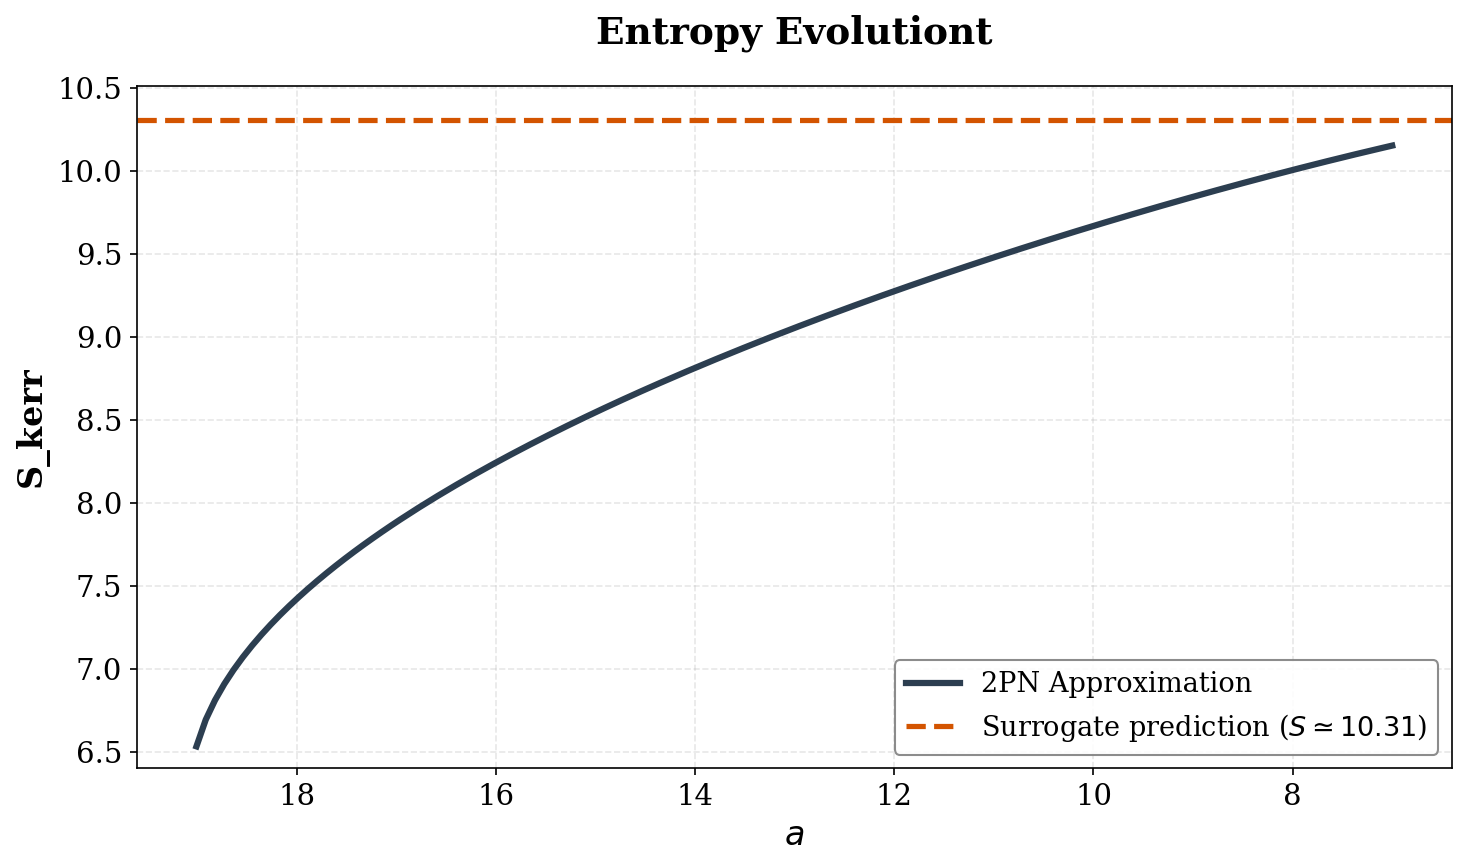

In [8]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(a, S, color='#2c3e50', lw=3.0, label=r'2PN Approximation')

ax.axhline(S_surr_final, color='#d35400', linestyle='--', lw=2.5, 
           label=rf'Surrogate prediction ($S \simeq {S_surr_final:.2f}$)')
ax.invert_xaxis()
ax.set_xlabel(r'$a$', fontweight='bold')
ax.set_ylabel(r'S_kerr', fontweight='bold')
ax.set_title(r'Entropy Evolutiont', fontweight='bold', pad=20)
y_min = min(np.nanmin(S), S_surr_final) * 0.98
y_max = max(np.nanmax(S), S_surr_final) * 1.02
ax.set_ylim(y_min, y_max)
ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9)
plt.tight_layout()
plt.show()

PADE' INTERPOLATION

In [9]:
def pade_2_1(x, p0, p1, p2, q1):
    return (p0 + p1 * x + p2 * x**2) / (1.0 + q1 * x)

In [10]:
valid_mask = ~np.isnan(S)
a_valid = a[valid_mask]
M_valid = M_array[valid_mask]
J_valid = J_array[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S[valid_mask][sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)

initial_guess = [1.0, 1.0, 1.0, 1.0]
lower_bounds = [-np.inf, -np.inf, -np.inf, 0.0]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

popt_M, _ = curve_fit(pade_2_1, x_fit, M_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)
popt_J, _ = curve_fit(pade_2_1, x_fit, J_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)

a_extrap = np.linspace(np.min(a_fit), 1.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = pade_2_1(x_extrap, *popt_M)
J_extrap = pade_2_1(x_extrap, *popt_J)
ENT_extrap = entropy(M_extrap, J_extrap)

a_full = np.concatenate([a_fit, a_extrap])
ENT_full = np.concatenate([S_fit, ENT_extrap])

idx_max = np.nanargmax(ENT_full)
a_max_entropy = a_full[idx_max]
S_max_entropy = ENT_full[idx_max]

print(f"Maximum with Padé at a =      {a_max_entropy:.3f}")
print("2PN Padé max entropy =       ", S_max_entropy)
print("Predicted entropy =          ", S_surr_final)
print("Delta S =                    ", np.abs(S_max_entropy - S_surr_final))

Maximum with Padé at a =      3.450
2PN Padé max entropy =        10.46622272315439
Predicted entropy =           10.306098068917818
Delta S =                     0.16012465423657218


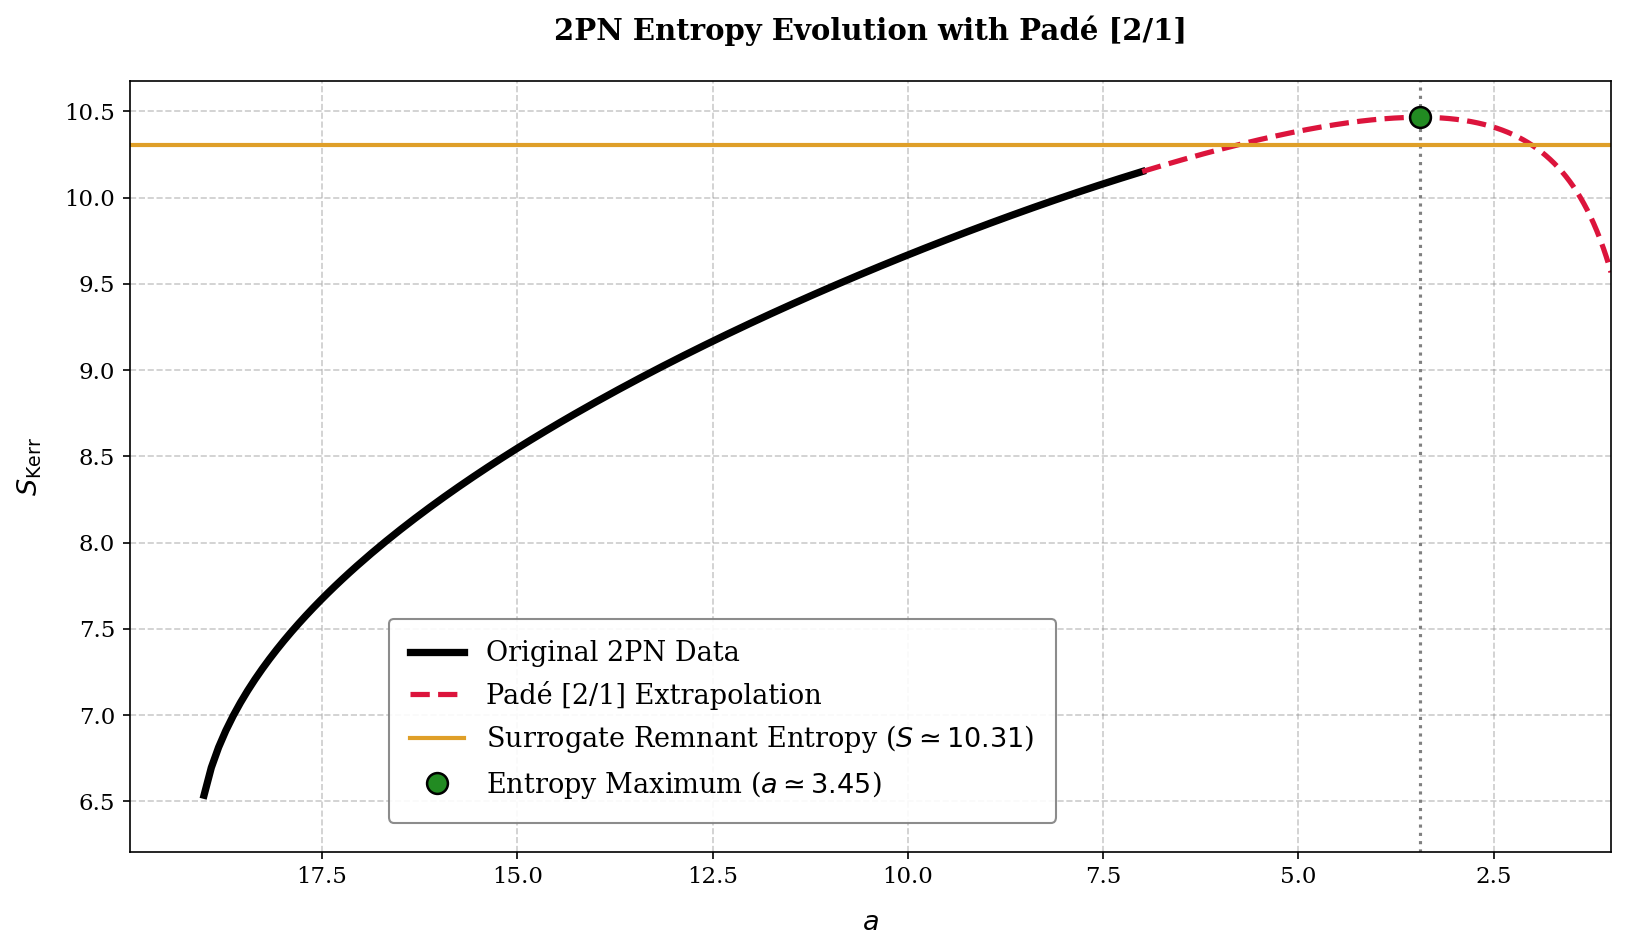

In [11]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
ax.plot(a_fit, S_fit, color='black', lw=3.5, label='Original 2PN Data')
ax.plot(a_extrap, ENT_extrap, color='#dc143c', linestyle='--', lw=2.5, label='Padé [2/1] Extrapolation')
ax.axhline(y=S_surr_final, color='#df9f28', lw=2.0, linestyle='-', 
           label=rf'Surrogate Remnant Entropy ($S \simeq {S_surr_final:.2f}$)')
ax.axvline(x=a_max_entropy, color='gray', linestyle=':', lw=1.5, zorder=1)
ax.plot(a_max_entropy, S_max_entropy, marker='o', color='#228b22', markersize=10, 
        markeredgecolor='black', markeredgewidth=1.2, linestyle='none', zorder=5,
        label=rf'Entropy Maximum ($a \simeq {a_max_entropy:.2f}$)')
ax.invert_xaxis()
x_max_plot = np.max(a_fit) * 1.05
ax.set_xlim(x_max_plot, 1.0)
y_min_plot = np.nanmin(S_fit) * 0.95
y_max_plot = max(S_max_entropy, S_surr_final) * 1.02
ax.set_ylim(y_min_plot, y_max_plot)
ax.set_xlabel(r'$a$', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title('2PN Entropy Evolution with Padé [2/1]', fontweight='bold', pad=20)
ax.grid(True, which='both', linestyle='--', alpha=0.4, color='gray')
ax.legend(loc='lower center', bbox_to_anchor=(0.4, 0.02), frameon=True, 
          facecolor='white', edgecolor='gray', framealpha=0.9, shadow=False, borderpad=0.8)

plt.tight_layout()
plt.show()

POLYNOMIAL INTERPOLATION

In [12]:
valid_mask = ~np.isnan(S)
a_valid = a[valid_mask]
M_valid = M_array[valid_mask]
J_valid = J_array[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S[valid_mask][sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)
degree = 4

poly_M = np.poly1d(np.polyfit(x_fit, M_fit, degree))
poly_J = np.poly1d(np.polyfit(x_fit, J_fit, degree))

a_extrap = np.linspace(np.min(a_fit), 1.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = poly_M(x_extrap)
J_extrap = poly_J(x_extrap)
ENT_extrap = entropy(M_extrap, J_extrap)

a_full = np.concatenate([a_fit, a_extrap])
ENT_full = np.concatenate([S_fit, ENT_extrap])

idx_max = np.nanargmax(ENT_full)
a_max_entropy = a_full[idx_max]
S_max_entropy = ENT_full[idx_max]

print(f"Maximum with Taylor at a =         {a_max_entropy:.3f}")
print("2PN Taylor max entropy =          ", S_max_entropy)
print("Predicted entropy =               ", S_surr_final)
print("Delta S =                         ", np.abs(S_max_entropy - S_surr_final))

Maximum with Taylor at a =         4.934
2PN Taylor max entropy =           10.336638765179096
Predicted entropy =                10.306098068917818
Delta S =                          0.0305406962612782


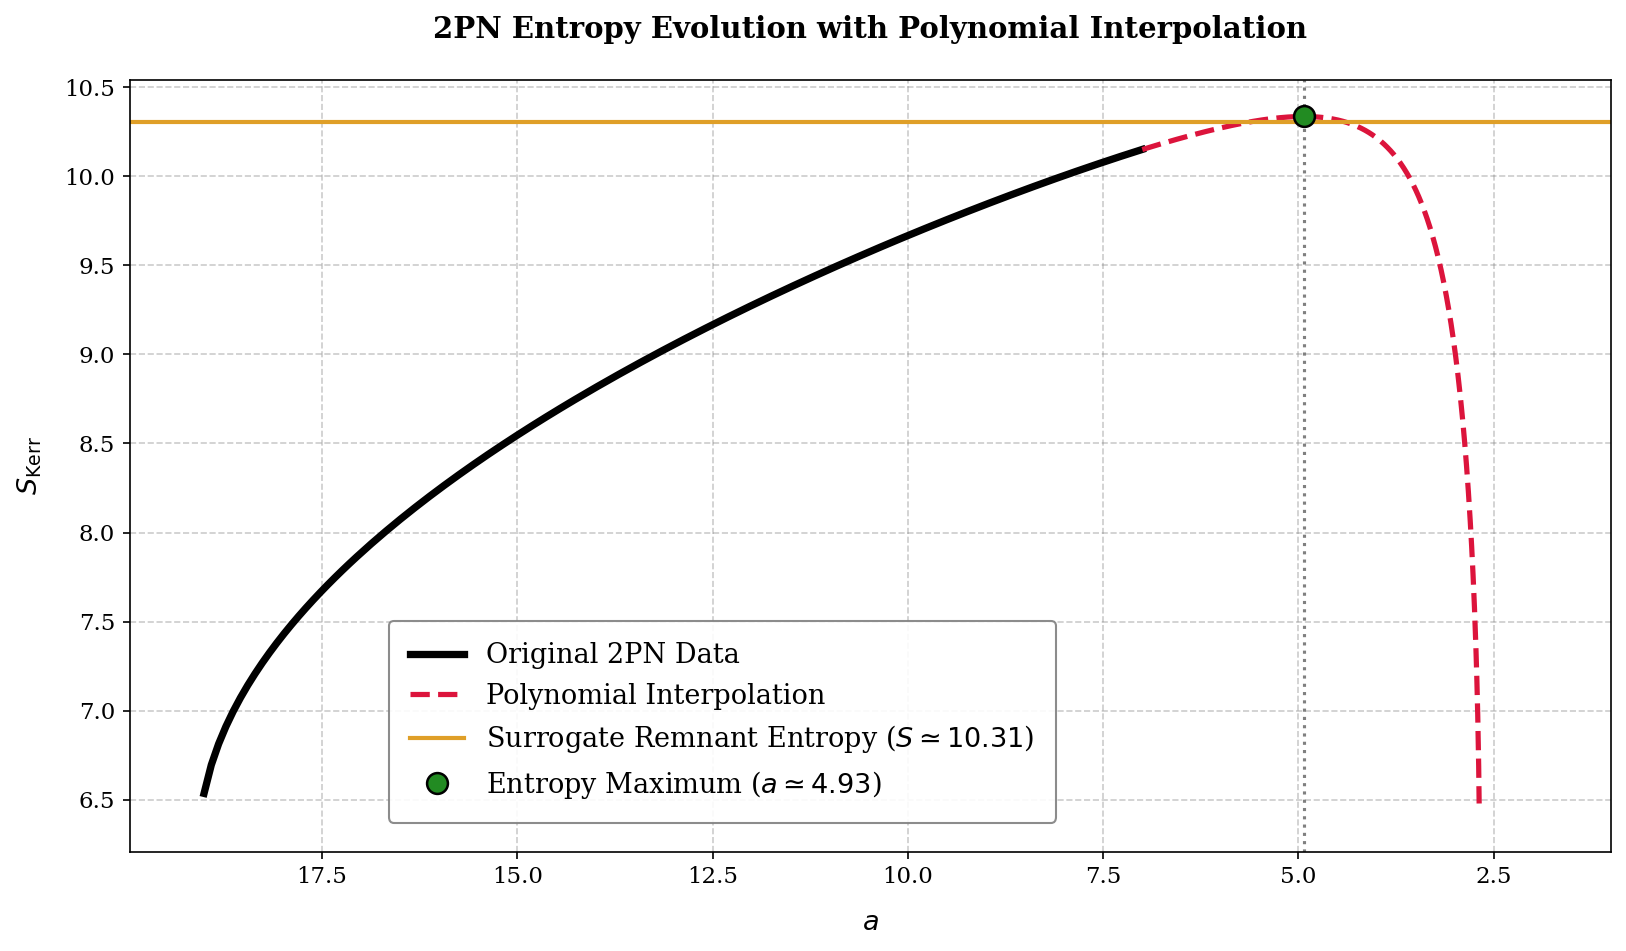

In [13]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
ax.plot(a_fit, S_fit, color='black', lw=3.5, label='Original 2PN Data')
ax.plot(a_extrap, ENT_extrap, color='#dc143c', linestyle='--', lw=2.5, label='Polynomial Interpolation')
ax.axhline(y=S_surr_final, color='#df9f28', lw=2.0, linestyle='-', 
           label=rf'Surrogate Remnant Entropy ($S \simeq {S_surr_final:.2f}$)')
ax.axvline(x=a_max_entropy, color='gray', linestyle=':', lw=1.5, zorder=1)
ax.plot(a_max_entropy, S_max_entropy, marker='o', color='#228b22', markersize=10, 
        markeredgecolor='black', markeredgewidth=1.2, linestyle='none', zorder=5,
        label=rf'Entropy Maximum ($a \simeq {a_max_entropy:.2f}$)')
ax.invert_xaxis()
x_max_plot = np.max(a_fit) * 1.05
ax.set_xlim(x_max_plot, 1.0)
y_min_plot = np.nanmin(S_fit) * 0.95
y_max_plot = max(S_max_entropy, S_surr_final) * 1.02
ax.set_ylim(y_min_plot, y_max_plot)
ax.set_xlabel(r'$a$', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title('2PN Entropy Evolution with Polynomial Interpolation', fontweight='bold', pad=20)
ax.grid(True, which='both', linestyle='--', alpha=0.4, color='gray')
ax.legend(loc='lower center', bbox_to_anchor=(0.4, 0.02), frameon=True, 
          facecolor='white', edgecolor='gray', framealpha=0.9, shadow=False, borderpad=0.8)

plt.tight_layout()
plt.show()

NR ANALYSIS

In [14]:
q = 3.0
m1 = q / (1.0 + q)
m2 = 1.0 / (1.0 + q)
eta = m1 * m2
chi1 = [0.0, 0.0, 0.3]
chi2 = [0.0, 0.0, 0.2]

times_NR = np.linspace(-1000, 0, 2000)

In [15]:
sur_wave_aligned = gws.LoadSurrogate('NRHybSur3dq8')
sur_remnant_aligned = surfinBH.LoadFits('NRSur3dq8Remnant')

Loaded NRHybSur3dq8 model
Loaded NRSur3dq8Remnant fit.


In [16]:
M_f, chi_f_array, _, _, _, _ = sur_remnant_aligned.all(q, chi1, chi2)
J_f = (M_f**2) * chi_f_array[2]
S_final = 2.0 * np.pi * (M_f**2) * (1.0 + np.sqrt(1.0 - (J_f/(M_f**2))**2))
print(S_final)

10.16131725054853


In [17]:
times_full = np.linspace(-5000, 0, 8000)
t_out, h_modes, _ = sur_wave_aligned(q, chi1, chi2, times=times_full, f_low=0)

dE_dt = np.zeros_like(t_out)
dJ_dt = np.zeros_like(t_out)

for (l, m), h in h_modes.items():
    dh_dt = np.gradient(h, t_out)
    dE_dt += (1.0 / (16.0 * np.pi)) * np.abs(dh_dt)**2
    dJ_dt += (1.0 / (16.0 * np.pi)) * m * np.imag(h * np.conjugate(dh_dt))

E_rad = cumulative_trapezoid(dE_dt, t_out, initial=0)
J_rad = cumulative_trapezoid(dJ_dt, t_out, initial=0)

M_init = M_f + E_rad[-1]  
J_init = J_f + J_rad[-1]

M_dyn = M_init - E_rad
J_dyn = J_init - J_rad


h22 = h_modes[(2, 2)]
phase22 = np.unwrap(np.angle(h22))
omega22 = np.gradient(phase22, t_out)
omega_orb = np.abs(omega22) / 2.0
r_sep = (np.maximum(omega_orb, 1e-8))**(-2/3)

a_spin_dyn = np.abs(J_dyn) / (M_dyn**2)

valid_kerr = a_spin_dyn <= 1.0

S_dyn = np.full_like(a_spin_dyn, np.nan)
S_dyn[valid_kerr] = 2.0 * np.pi * (M_dyn[valid_kerr]**2) * (1.0 + np.sqrt(1.0 - a_spin_dyn[valid_kerr]**2))

cutoff_idx = np.searchsorted(t_out, -12.0)
r_plot = r_sep[:cutoff_idx]
S_plot = S_dyn[:cutoff_idx]

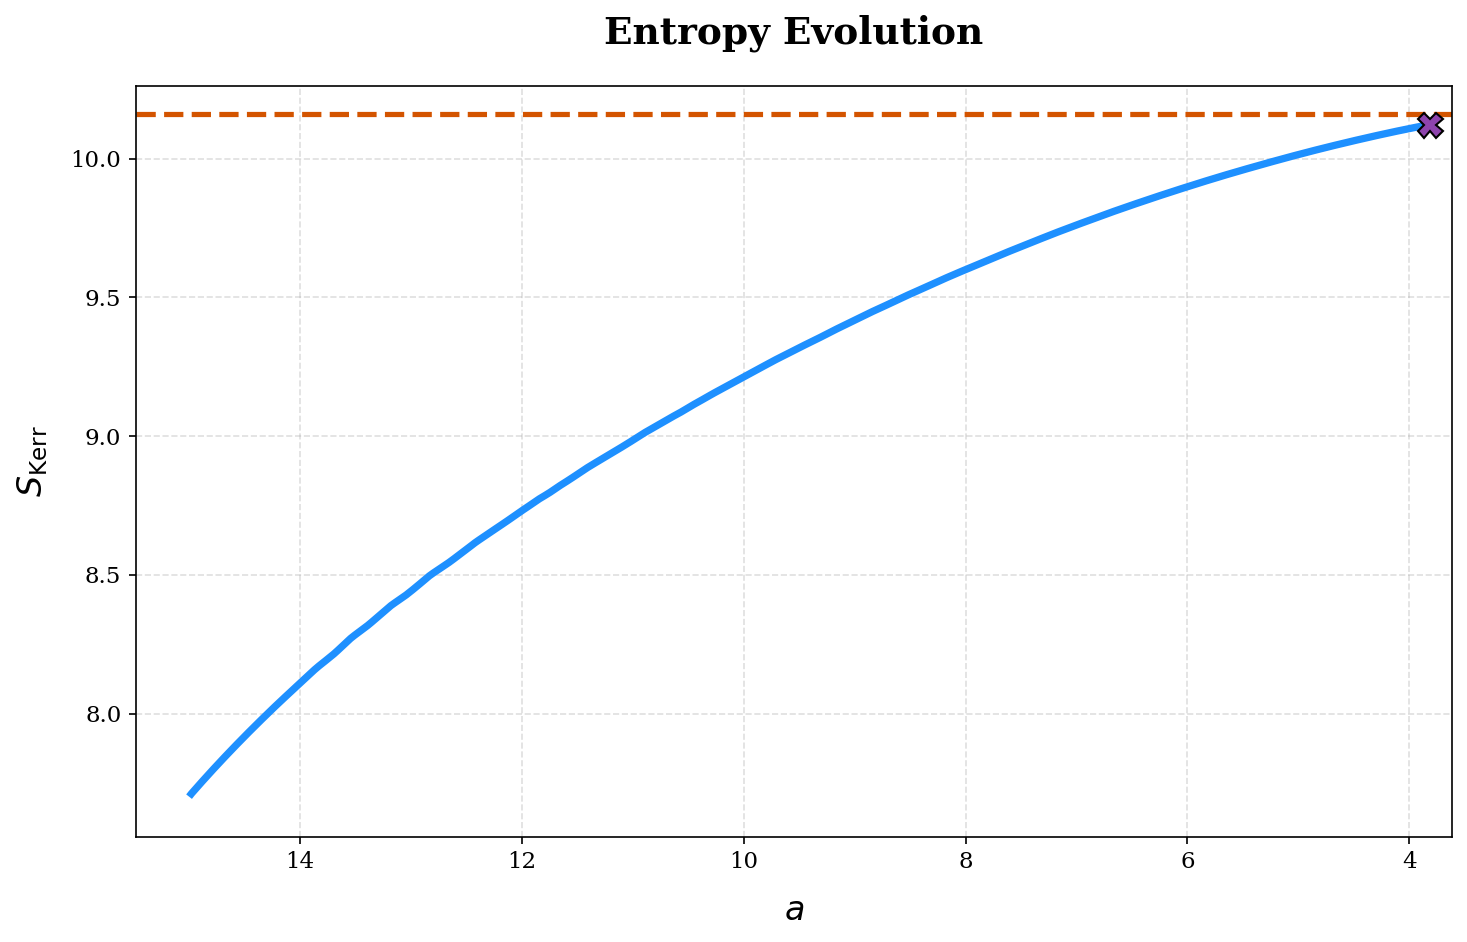

In [18]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 13
})

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=150)
ax.plot(r_plot, S_plot, color='#1e90ff', lw=3.5)
ax.axhline(S_final, color='#d35400', linestyle='--', lw=2.5)
valid_r_values = r_plot[~np.isnan(S_plot)]
if len(valid_r_values) > 0:
    r_start_plot = valid_r_values[0]
else:
    r_start_plot = 15.0
ax.invert_xaxis()
ax.set_xlim(r_start_plot + 0.5, r_plot[-1] - 0.2)
y_min = np.nanmin(S_plot) * 0.98
y_max = S_final * 1.01
ax.set_ylim(y_min, y_max)
ax.plot(r_plot[-1], S_plot[-1], marker='X', color='#8e44ad', markersize=12, 
        markeredgecolor='black', linestyle='none', zorder=5)
ax.set_xlabel(r'$a$', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title(r'Entropy Evolution', fontweight='bold', pad=20)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

BREAKDOWN OF THE POST-NEWTONIAN FORMALISM

Symmetric Spin

In [19]:
def analyze_configuration_symmetric(q, chi_val,a):
    
    spin1 = [0.0, 0.0, chi_val]
    spin2 = [0.0, 0.0, chi_val]
    
    mf, chif_vec, *_ = sur_remnant_aligned.all(q, spin1, spin2)
    Jf = np.linalg.norm(chif_vec) * (mf**2)
    S_final = 2.0 * np.pi * (mf**2) * (1.0 + np.sqrt(1.0 - (Jf/(mf**2))**2))

    M_arr, J_arr, S_arr, max_2pn = get_max_2PN(q, chi_val, chi_val, a)
    
    return {
        "q": q,
        "chi": chi_val,
        "S_NR": S_final,
        "S_2PN_max": max_2pn,
        "Delta_S": np.abs(max_2pn - S_final)
    }

In [20]:
q_list = np.linspace(1,8,30)
chi_list = np.linspace(0.1,0.8,30)
a_2 = np.linspace(100.0,7.0, 1000)

results = []

for q in q_list:
    for chi in chi_list:
        try:
            res = analyze_configuration_symmetric(q, chi,a_2)
            results.append(res)
        except Exception as e:
            print(f"Skipping q={q}, chi={chi}: {e}")

df_results = pd.DataFrame(results)

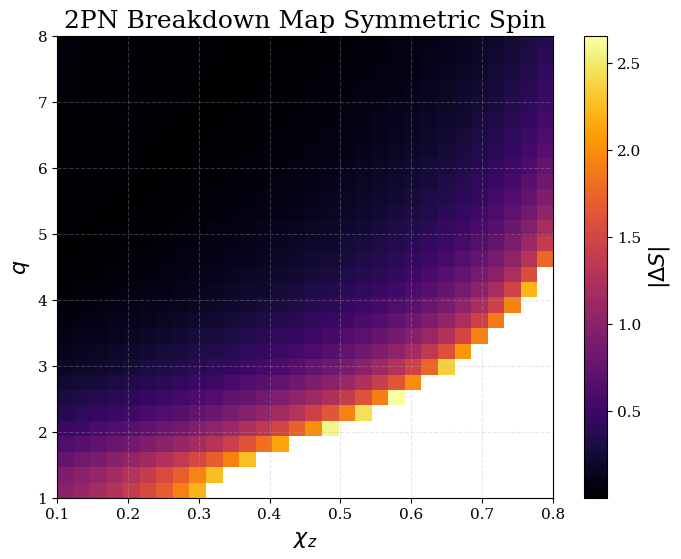

In [21]:

pivot_data = df_results.pivot(index="q", columns="chi", values="Delta_S")

plt.figure(figsize=(8, 6))
plt.imshow(pivot_data, aspect='auto', cmap='inferno', origin='lower',
           extent=[min(chi_list), max(chi_list), min(q_list), max(q_list)])
plt.colorbar(label=r'$|\Delta S|$')
plt.xlabel(r'$\chi_z$')
plt.ylabel(r'$q$')
plt.title('2PN Breakdown Map Symmetric Spin')
plt.show()

Asymmetric spin

In [22]:
def analyze_configuration_asymmetric(q, chi1, chi2, a):

    spin1 = [0.0, 0.0, chi1]
    spin2 = [0.0, 0.0, chi2]
    
    mf, chif_vec, *_ = sur_remnant_aligned.all(q, spin1, spin2)
        
    chi_f_nr = np.linalg.norm(chif_vec)
    S_final_nr = entropy(mf,chi_f_nr)
    M_arr, J_arr, S_arr, max_2pn = get_max_2PN(q, chi1, chi2, a)
    
    return {
        "q": q,
        "delta_chi": chi1 - chi2,
        "chi_avg": (chi1 + chi2) / 2.0, # Utile per tenere costante il momento
        "Delta_S": np.abs(max_2pn - S_final_nr)
    }

In [23]:
results = []
spin_range = np.linspace(-0.8, 0.8, 30) 
q_range = np.linspace(1,8,30)
a_3 = np.linspace(100.0,7.0, 1000)

for q in q_range:
    for chi1 in spin_range:
        for chi2 in spin_range:
            if abs(chi1) > 0.8 or abs(chi2) > 0.8: continue
            
            res = analyze_configuration_asymmetric(q, chi1, chi2, a_3)
            results.append(res)

df = pd.DataFrame(results)

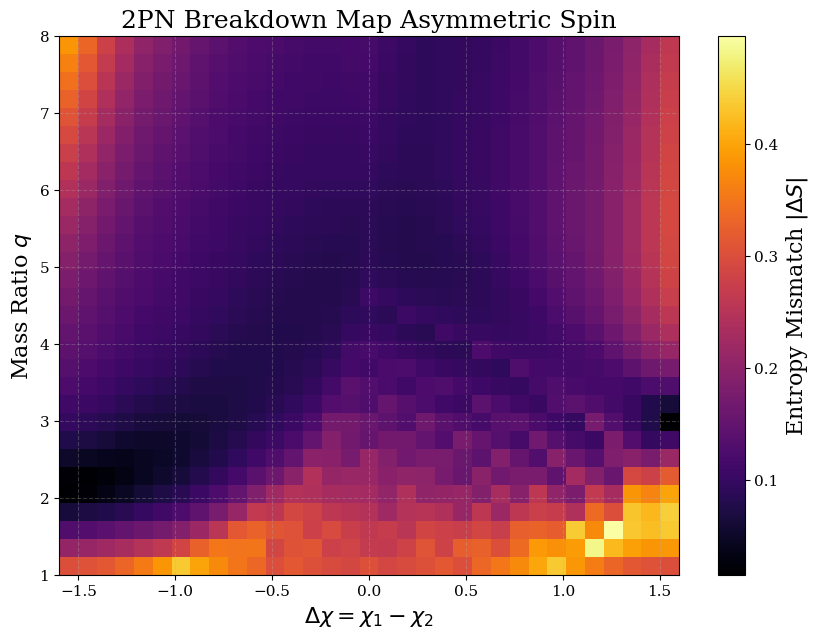

In [24]:
df['delta_chi_rounded'] = df['delta_chi'].round(1)
pivot_map = df.pivot_table(index="q", columns="delta_chi_rounded", values="Delta_S", aggfunc='mean')

# Plot
plt.figure(figsize=(10, 7))
plt.imshow(pivot_map, aspect='auto', origin='lower', cmap='inferno',
           extent=[pivot_map.columns.min(), pivot_map.columns.max(), 
                   pivot_map.index.min(), pivot_map.index.max()])
plt.colorbar(label=r'Entropy Mismatch $|\Delta S|$')
plt.xlabel(r'$\Delta \chi = \chi_1 - \chi_2$')
plt.ylabel(r'Mass Ratio $q$')
plt.title(r'2PN Breakdown Map Asymmetric Spin')
plt.show()

BREAKDOWN OF PADE' INTERPOLATION

Symmetric Spin with Padè

In [55]:
def analyze_configuration_pade_symmetric(q, chi_val, a_array):
    
    result_fail = {
        "q": q, "chi": chi_val, "S_NR": np.nan, 
        "S_Pade_max": np.nan, "Delta_S": np.nan
    }
    
    try:
        spin1 = [0.0, 0.0, chi_val]
        spin2 = [0.0, 0.0, chi_val]
  
        mf, chif_vec, *_ = sur_remnant_aligned.all(q, spin1, spin2)
            
        chi_f_nr = np.linalg.norm(chif_vec)
        
        Jf = chi_f_nr * (mf**2)
        S_final_nr = entropy(mf, Jf)

        M_arr, J_arr, S_arr, _ = get_max_2PN(q, chi_val, chi_val, a_array)

        valid_mask = ~np.isnan(S_arr)
        if np.sum(valid_mask) < 4:  
            result_fail["S_NR"] = float(S_final_nr)
            return result_fail
            
        x_data = 1.0 / np.sqrt(a_array[valid_mask])
        M_data = M_arr[valid_mask]
        J_data = J_arr[valid_mask]
        
        popt_M, _ = curve_fit(pade_2_1, x_data, M_data, p0=[1,1,1,0.1], maxfev=5000)
        popt_J, _ = curve_fit(pade_2_1, x_data, J_data, p0=[1,1,1,0.1], maxfev=5000)
            
        r_extrap = np.linspace(25.0, 1.5, 2000)
        x_extrap = 1.0 / np.sqrt(r_extrap)
            
        M_Pade = pade_2_1(x_extrap, *popt_M)
        J_Pade = pade_2_1(x_extrap, *popt_J)
            
        S_Pade = entropy(M_Pade, J_Pade)
        
        if np.all(np.isnan(S_Pade)):
            result_fail["S_NR"] = float(S_final_nr)
            return result_fail
            
        max_pade = np.nanmax(S_Pade)
            
        return {
            "q": q, 
            "chi": chi_val, 
            "S_NR": float(S_final_nr),
            "S_Pade_max": float(max_pade),
            "Delta_S": float(np.abs(max_pade - S_final_nr))
        }
        
    except Exception as e:
        
        return result_fail

In [56]:
q_list = np.linspace(1, 8, 30)
chi_list = np.linspace(0.1, 0.8, 30)
a_2 = np.linspace(100.0, 7.0, 1000)

results = []

for q in q_list:
    for chi in chi_list:
        res = analyze_configuration_pade_symmetric(q, chi, a_2)
        results.append(res)

df_results = pd.DataFrame(results)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


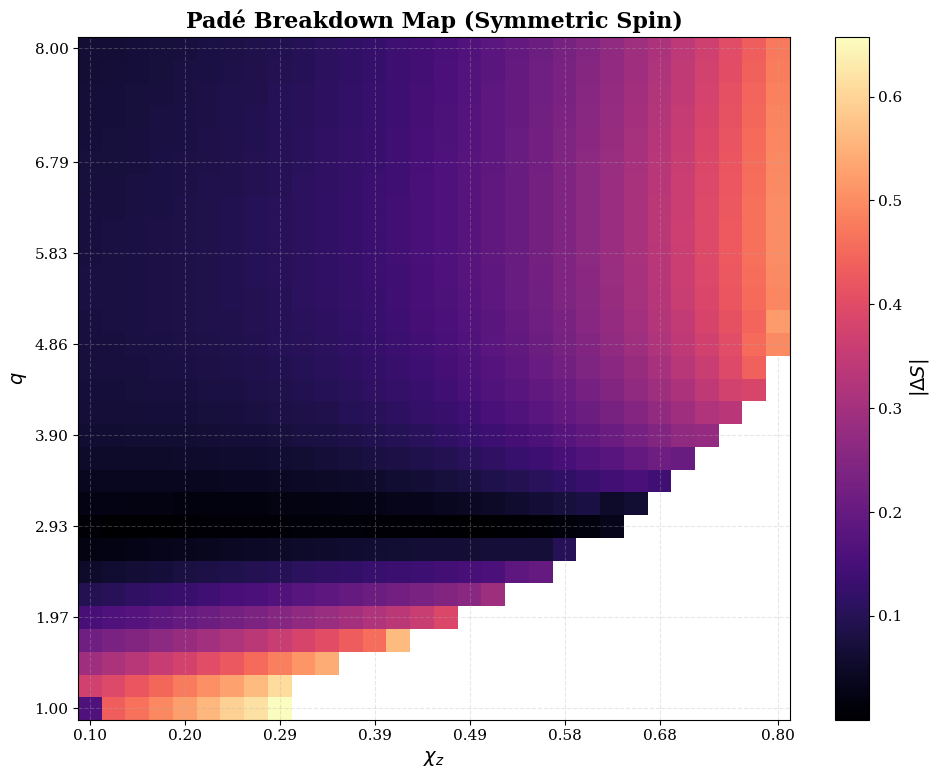

In [57]:
df_clean = df_results.dropna(subset=['Delta_S'])
df_clean['q_bin'] = df_clean['q'].round(2)
df_clean['chi_bin'] = df_clean['chi'].round(2)

heatmap_data = df_clean.pivot_table(index="q_bin", columns="chi_bin", values="Delta_S")

x_labels = heatmap_data.columns.values
y_labels = heatmap_data.index.values

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data.values, cmap='magma', aspect='auto', origin='lower')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$|\Delta S|$', fontsize=14)

num_ticks = 8
x_idx = np.linspace(0, len(x_labels)-1, num_ticks, dtype=int)
y_idx = np.linspace(0, len(y_labels)-1, num_ticks, dtype=int)

ax.set_xticks(x_idx)
ax.set_yticks(y_idx)
ax.set_xticklabels([f"{x_labels[i]:.2f}" for i in x_idx])
ax.set_yticklabels([f"{y_labels[i]:.2f}" for i in y_idx])

plt.title('Padé Breakdown Map (Symmetric Spin)', fontsize=16, fontweight='bold')
plt.xlabel(r'$\chi_z$', fontsize=14)
plt.ylabel(r'$q$', fontsize=14)

plt.tight_layout()
plt.show()

Asymmetric Spin with Padè

In [61]:
def analyze_configuration_pade_asymmetric(q, chi1, chi2, a_array):
    
    result_fail = {
        "q": q, "chi1": chi1, "chi2": chi2, 
        "delta_chi": chi1 - chi2,
        "S_NR": np.nan, "S_Pade_max": np.nan, "Delta_S": np.nan
    }
    
    try:
    
        spin1 = [0.0, 0.0, chi1]
        spin2 = [0.0, 0.0, chi2]
        
        mf, chif_vec, *_ = sur_remnant_aligned.all(q, spin1, spin2)
            
        chi_f_nr = np.linalg.norm(chif_vec)
        
        Jf = chi_f_nr * (mf**2)
        S_final_nr = entropy(mf, Jf)

        if np.isnan(S_final_nr): return result_fail

        M_arr, J_arr, S_arr, _ = get_max_2PN(q, chi1, chi2, a_array)

        if S_arr is None or np.all(np.isnan(S_arr)):
             result_fail["S_NR"] = float(S_final_nr)
             return result_fail

        valid_mask = ~np.isnan(S_arr)
        x_data = 1.0 / np.sqrt(a_array[valid_mask])
        M_data = M_arr[valid_mask]
        J_data = J_arr[valid_mask]

        if len(x_data) < 4 or np.any(np.isnan(M_data)) or np.any(np.isnan(J_data)):
            result_fail["S_NR"] = float(S_final_nr) 
            return result_fail
        

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt_M, _ = curve_fit(pade_2_1, x_data, M_data, p0=[1,1,1,0.1], maxfev=5000)
            popt_J, _ = curve_fit(pade_2_1, x_data, J_data, p0=[1,1,1,0.1], maxfev=5000)
            
  
        r_extrap = np.linspace(25.0, 1.5, 2000)
        x_extrap = 1.0 / np.sqrt(r_extrap)
            
        M_Pade = pade_2_1(x_extrap, *popt_M)
        J_Pade = pade_2_1(x_extrap, *popt_J)
        S_Pade = entropy(M_Pade, J_Pade)
        
        if np.all(np.isnan(S_Pade)):
            result_fail["S_NR"] = float(S_final_nr)
            return result_fail
            
        max_pade = np.nanmax(S_Pade)
            
        return {
            "q": q, 
            "chi1": chi1,
            "chi2": chi2,
            "delta_chi": chi1 - chi2,
            "S_NR": float(S_final_nr),
            "S_Pade_max": float(max_pade),
            "Delta_S": float(np.abs(max_pade - S_final_nr))
        }
        
    except Exception:
        result_fail["S_NR"] = float(S_final_nr) if 'S_final_nr' in locals() else np.nan
        return result_fail

In [62]:
results = []
spin_range = np.linspace(-0.8, 0.8, 15) 
q_range = np.linspace(1, 8, 15)
a_3 = np.linspace(100.0, 7.0, 1000)

for q in q_range:
    for chi1 in spin_range:
        for chi2 in spin_range:
            if abs(chi1) > 0.8 or abs(chi2) > 0.8: continue
            
            res = analyze_configuration_pade_asymmetric(q, chi1, chi2, a_3)
            results.append(res)

df_asym = pd.DataFrame(results)

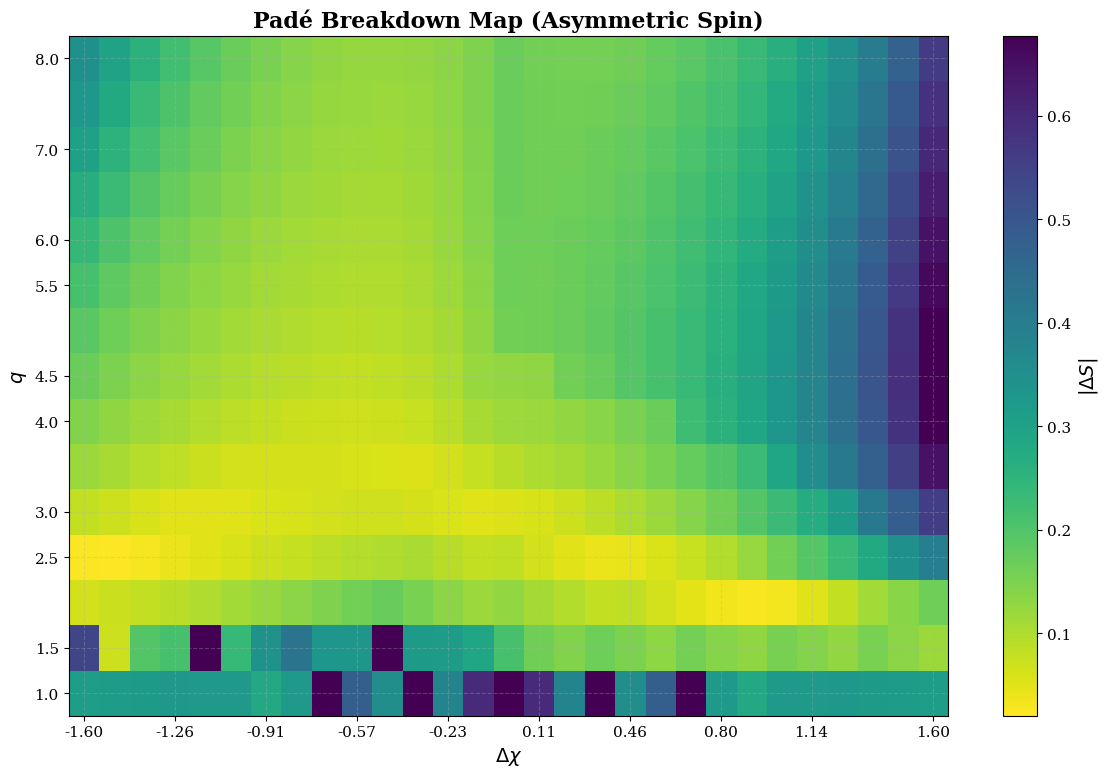

In [69]:
df_clean = df_asym.dropna(subset=['Delta_S'])

df_clean['q_bin'] = df_clean['q'].round(1)
df_clean['delta_chi_bin'] = df_clean['delta_chi'].round(2)

heatmap_data = df_clean.pivot_table(index="q_bin", columns="delta_chi_bin", values="Delta_S")

x_labels = heatmap_data.columns.values
y_labels = heatmap_data.index.values

valori_validi = heatmap_data.values[~np.isnan(heatmap_data.values)]
limite_vmax = np.percentile(valori_validi, 98) 

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(heatmap_data.values, cmap='viridis_r', aspect='auto', origin='lower', vmax=limite_vmax)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$|\Delta S|$', fontsize=14)

num_x_ticks = min(10, len(x_labels))
num_y_ticks = min(10, len(y_labels))

x_idx = np.linspace(0, len(x_labels)-1, num_x_ticks, dtype=int)
y_idx = np.linspace(0, len(y_labels)-1, num_y_ticks, dtype=int)

ax.set_xticks(x_idx)
ax.set_yticks(y_idx)
ax.set_xticklabels([f"{x_labels[i]:.2f}" for i in x_idx])
ax.set_yticklabels([f"{y_labels[i]:.1f}" for i in y_idx])

plt.title('Padé Breakdown Map (Asymmetric Spin)', fontsize=16, fontweight='bold')
plt.xlabel(r'$\Delta \chi$', fontsize=14)
plt.ylabel(r'$q$', fontsize=14)

plt.tight_layout()
plt.show()

DELTA a ANALYSIS

In [133]:
q_test = 4   
chi1_test = 0.5    
chi2_test = -0.2  

a_array = np.linspace(100.0, 7.0, 1000) 

spin1 = [0.0, 0.0, chi1_test]
spin2 = [0.0, 0.0, chi2_test]

In [134]:

times_full = np.linspace(-5000, 50, 4000)
t_out, h_modes, _ = sur_wave_aligned(q_test, spin1, spin2, times=times_full, f_low=0)
h22 = h_modes[(2, 2)]
phase22 = np.unwrap(np.angle(h22))
omega_orb = np.abs(np.gradient(phase22, t_out)) / 2.0
r_sep_nr = (np.maximum(omega_orb, 1e-8))**(-2/3)
idx_merger_NR = np.argmin(np.abs(t_out))
r_merger_NR = r_sep_nr[idx_merger_NR]

r_extrap = np.linspace(25.0, 1.2, 3000)
x_extrap = 1.0 / np.sqrt(r_extrap)

# 2PN DATA
M_arr, J_arr, S_arr, _ = get_max_2PN(q_test, chi1_test, chi2_test, a_array)
valid_mask = ~np.isnan(S_arr)
x_data = 1.0 / np.sqrt(a_array[valid_mask])
M_data = M_arr[valid_mask]
J_data = J_arr[valid_mask]

# Padé 
popt_M, _ = curve_fit(pade_2_1, x_data, M_data, p0=[1,1,1,0.1], maxfev=5000)
popt_J, _ = curve_fit(pade_2_1, x_data, J_data, p0=[1,1,1,0.1], maxfev=5000)
M_Pade = pade_2_1(x_extrap, *popt_M)
J_Pade = pade_2_1(x_extrap, *popt_J)
S_Pade_extrap = entropy(M_Pade, J_Pade)
idx_max_S_Pade = np.nanargmax(S_Pade_extrap)
r_merger_Pade = r_extrap[idx_max_S_Pade]
S_max_Pade = S_Pade_extrap[idx_max_S_Pade]

# Taylor 
poly_M = np.polyfit(x_data, M_data, 3)
poly_J = np.polyfit(x_data, J_data, 3)
M_Taylor = np.polyval(poly_M, x_extrap)
J_Taylor = np.polyval(poly_J, x_extrap)
S_Taylor_extrap = entropy(M_Taylor, J_Taylor)
idx_max_S_Taylor = np.nanargmax(S_Taylor_extrap)
r_merger_Taylor = r_extrap[idx_max_S_Taylor]
S_max_Taylor = S_Taylor_extrap[idx_max_S_Taylor]


delta_r_Pade = np.abs(r_merger_NR - r_merger_Pade)
delta_r_Taylor = np.abs(r_merger_NR - r_merger_Taylor)

print(f"NR separation at merger      = {r_merger_NR:.4f} M")
print("-" * 50)
print(f"Taylor's Peak Entropy at a   = {r_merger_Taylor:.4f} M")
print(f"Taylor Delta a               = {delta_r_Taylor:.4f} M")
print("-" * 50)
print(f"Padé's Peak Entropy at a     = {r_merger_Pade:.4f} M")
print(f"Padé Delta a                 = {delta_r_Pade:.4f} M")

NR separation at merger      = 3.0846 M
--------------------------------------------------
Taylor's Peak Entropy at a   = 1.9380 M
Taylor Delta a               = 1.1465 M
--------------------------------------------------
Padé's Peak Entropy at a     = 3.0253 M
Padé Delta a                 = 0.0593 M


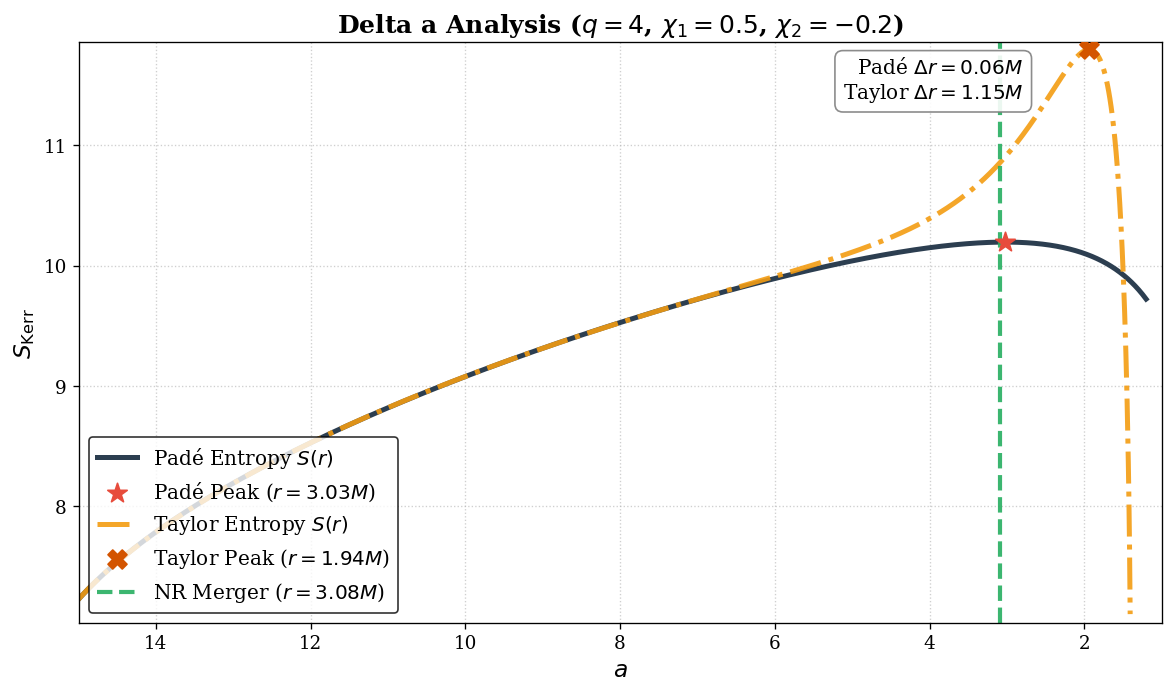

In [135]:
plt.figure(figsize=(10, 6), dpi=120)
plt.plot(r_extrap, S_Pade_extrap, lw=3, color='#2c3e50', label='Padé Entropy $S(r)$')
plt.scatter(r_merger_Pade, S_max_Pade, color='#e74c3c', s=150, zorder=5, marker='*', 
            label=rf'Padé Peak ($r={r_merger_Pade:.2f}M$)')
plt.plot(r_extrap, S_Taylor_extrap, lw=3, color='#f39c12', linestyle='-.', alpha=0.9, 
         label='Taylor Entropy $S(r)$')
plt.scatter(r_merger_Taylor, S_max_Taylor, color='#d35400', s=130, zorder=5, marker='X', 
            label=rf'Taylor Peak ($r={r_merger_Taylor:.2f}M$)')
plt.axvline(r_merger_NR, color='#27ae60', linestyle='--', lw=2.5, alpha=0.9,
            label=rf'NR Merger ($r={r_merger_NR:.2f}M$)')
box_text = (rf'Padé $\Delta r = {delta_r_Pade:.2f}M$' + '\n' +
            rf'Taylor $\Delta r = {delta_r_Taylor:.2f}M$')
max_y_val = max(S_max_Pade, S_max_Taylor)
plt.annotate(box_text, 
             xy=(r_merger_NR, max_y_val * 0.995),
             xytext=(r_merger_NR - 0.3, max_y_val * 0.995), 
             ha='right', va='top', fontsize=12, color='black',
             bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='gray', alpha=0.9))
plt.gca().invert_xaxis()
plt.xlim(15.0, 1.0) 

y_min_pade = np.nanmin(S_Pade_extrap[r_extrap < 15.0])
y_min_taylor = np.nanmin(S_Taylor_extrap[r_extrap < 15.0])
y_min = min(y_min_pade, y_min_taylor)
plt.ylim(y_min * 0.99, max_y_val * 1.005)
plt.xlabel(r'$a$', fontsize=14)
plt.ylabel(r'$S_{\mathrm{Kerr}}$', fontsize=14)
plt.title(rf'Delta a Analysis ($q={q_test}$, $\chi_1={chi1_test}$, $\chi_2={chi2_test}$)', fontsize=15, fontweight='bold')
plt.legend(loc='lower left', fontsize=12, frameon=True, edgecolor='black')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()